<div style="text-align: center;">
    <h1>K-Nearest Neighbors — Clasificación de Enfermedad Cardiovascular</h1>
</div>

Este notebook implementa un modelo **K-Nearest Neighbors (KNN)** siguiendo el mismo flujo usado para SVM y MLP:

1. carga de datos limpios;
2. separación `train / validation / test`;
3. preprocesamiento reproducible con `Pipeline`;
4. modelos base;
5. búsqueda de hiperparámetros;
6. selección oficial por **ROC-AUC**;
7. ajuste de threshold por **F2-score** en validación;
8. evaluación final en test;
9. exportación del modelo entrenado.


## 1. Importar librerías

In [1]:
from pathlib import Path
import itertools
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV,
    KFold
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.dummy import DummyClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    make_scorer,
    RocCurveDisplay
)

## 2. Cargar datos

Se carga la base de datos limpia desde el repositorio del proyecto.

In [2]:
try:
    data = pd.read_csv(
        "https://raw.githubusercontent.com/SantCorrea802/Cardiovascular_Disease_Proyecto_Modelos_II/main/dataset/data_cleaned.csv"
    )
except FileNotFoundError:
    print("No se ha encontrado el archivo de datos. Verifique el directorio.")
    raise

data.head()

,age,gender,height,weight,systolic_blood_pressure,diastolic_blood_pressure,cholesterol,glucose,smoke,alcohol_intake,physical_activity,bmi,cardiovascular_disease
0,50,2,168,62.0,110,80,1,1,0,0,1,1,0
1,55,1,156,85.0,140,90,3,1,0,0,1,3,1
2,52,1,165,64.0,130,70,3,1,0,0,0,1,1
3,48,2,169,82.0,150,100,1,1,0,0,1,2,1
4,48,1,156,56.0,100,60,1,1,0,0,0,1,0


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68589 entries, 0 to 68588
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       68589 non-null  int64  
 1   gender                    68589 non-null  int64  
 2   height                    68589 non-null  int64  
 3   weight                    68589 non-null  float64
 4   systolic_blood_pressure   68589 non-null  int64  
 5   diastolic_blood_pressure  68589 non-null  int64  
 6   cholesterol               68589 non-null  int64  
 7   glucose                   68589 non-null  int64  
 8   smoke                     68589 non-null  int64  
 9   alcohol_intake            68589 non-null  int64  
 10  physical_activity         68589 non-null  int64  
 11  bmi                       68589 non-null  int64  
 12  cardiovascular_disease    68589 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.8 MB


## 3. Separación Train / Validation / Test

Se usa la misma estrategia del proyecto:

- 80% entrenamiento;
- 10% validación;
- 10% test.

El conjunto de test se mantiene reservado para la evaluación final.

In [4]:
target_column = "cardiovascular_disease"

if target_column not in data.columns:
    raise ValueError(f"No existe la columna objetivo: {target_column}")

features = data.drop(columns=[target_column])
target = data[target_column]

X_train, X_temp, y_train, y_temp = train_test_split(
    features,
    target,
    test_size=0.20,
    random_state=42,
    stratify=target
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("X_train:", X_train.shape)
print("X_val:  ", X_val.shape)
print("X_test: ", X_test.shape)
print("y_train:", y_train.shape)
print("y_val:  ", y_val.shape)
print("y_test: ", y_test.shape)

X_train: (54871, 12)
X_val:   (6859, 12)
X_test:  (6859, 12)
y_train: (54871,)
y_val:   (6859,)
y_test:  (6859,)


## 4. Definición de tipos de variables

Se conserva la misma separación usada en los notebooks de SVM y MLP.

In [5]:
categorical = [
    "gender",
    "cholesterol",
    "glucose",
    "smoke",
    "alcohol_intake",
    "physical_activity",
    "bmi"
]

nominal = [
    "gender",
    "smoke",
    "alcohol_intake",
    "physical_activity"
]

ordinal = [
    "cholesterol",
    "glucose",
    "bmi"
]

numerical = [
    col for col in X_train.columns
    if col not in categorical
]

print("Numerical:", numerical)
print("Nominal:", nominal)
print("Ordinal:", ordinal)

Numerical: ['age', 'height', 'weight', 'systolic_blood_pressure', 'diastolic_blood_pressure']
Nominal: ['gender', 'smoke', 'alcohol_intake', 'physical_activity']
Ordinal: ['cholesterol', 'glucose', 'bmi']


## 5. Preprocesamiento para KNN

KNN depende directamente de distancias. Por eso, el escalado de variables numéricas es obligatorio. Además:

- las variables nominales se codifican con One-Hot Encoding;
- las ordinales conservan su orden natural y luego se escalan;
- todo se encapsula dentro de un `Pipeline` para evitar fuga de información.

In [6]:
def build_one_hot_encoder():
    """Compatibilidad entre versiones de scikit-learn."""
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


ordinal_categories = [
    [1, 2, 3],              # cholesterol
    [1, 2, 3],              # glucose
    [0, 1, 2, 3, 4, 5]      # bmi
]

ordinal_pipeline = Pipeline(
    steps=[
        ("encoder", OrdinalEncoder(
            categories=ordinal_categories,
            handle_unknown="use_encoded_value",
            unknown_value=-1,
            encoded_missing_value=-2
        )),
        ("scaler", StandardScaler())
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical),
        ("nom", build_one_hot_encoder(), nominal),
        ("ord", ordinal_pipeline, ordinal)
    ],
    remainder="drop",
    sparse_threshold=0
)

## 6. Funciones auxiliares de métricas

Se reportan las mismas métricas usadas en SVM y MLP:

- accuracy;
- precision;
- recall;
- F1;
- F2;
- ROC-AUC;
- TN, FP, FN, TP;
- matriz de confusión con porcentajes por clase real.

In [7]:
def get_decision_scores(model, X):
    """
    Retorna scores continuos para ROC-AUC y ajuste de threshold.

    Para KNN se usa predict_proba(X)[:, 1].
    """
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]

    if hasattr(model, "decision_function"):
        return model.decision_function(X)

    raise AttributeError(
        "El modelo no expone predict_proba ni decision_function; no se puede calcular ROC-AUC."
    )


def get_scores_from_predictions(y_true, y_pred, y_score, model_name, split_name):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    return {
        "model": model_name,
        "split": split_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "f2": fbeta_score(y_true, y_pred, beta=2, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_score),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    }, cm


def get_scores(model, X, y, model_name, split_name, threshold=0.5):
    y_score = get_decision_scores(model, X)
    y_pred = (y_score >= threshold).astype(int)

    return get_scores_from_predictions(
        y_true=y,
        y_pred=y_pred,
        y_score=y_score,
        model_name=model_name,
        split_name=split_name
    )


def plot_confusion_matrix_percent(cm, title, class_labels=("Clase 0", "Clase 1"), save_path=None):
    """
    Grafica matriz de confusión con conteos y porcentajes por clase real.

    Porcentaje por fila:
    - Fila Real 0: TN y FP suman 100%.
    - Fila Real 1: FN y TP suman 100%.
    """
    cm = np.asarray(cm)

    row_totals = cm.sum(axis=1, keepdims=True)
    cm_percent = np.divide(
        cm,
        row_totals,
        out=np.zeros_like(cm, dtype=float),
        where=row_totals != 0
    ) * 100

    annotations = np.empty_like(cm, dtype=object)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            annotations[i, j] = f"{cm[i, j]}\n{cm_percent[i, j]:.1f}%"

    plt.figure(figsize=(5.8, 4.6))

    sns.heatmap(
        cm_percent,
        annot=annotations,
        fmt="",
        cmap="Blues",
        vmin=0,
        vmax=100,
        xticklabels=[f"Pred {label}" for label in class_labels],
        yticklabels=[f"Real {label}" for label in class_labels],
        cbar_kws={"label": "% por clase real"}
    )

    plt.xlabel("Predicción")
    plt.ylabel("Valor real")
    plt.title(title)
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

## 7. Scorers para búsqueda de hiperparámetros

La búsqueda calcula varias métricas, pero la selección oficial usa:

```python
refit="roc_auc"
```

Esto mantiene consistencia con SVM, MLP y Random Forest.

In [8]:
precision_scorer = make_scorer(
    precision_score,
    zero_division=0
)

recall_scorer = make_scorer(
    recall_score,
    zero_division=0
)

f1_scorer = make_scorer(
    f1_score,
    zero_division=0
)

f2_scorer = make_scorer(
    fbeta_score,
    beta=2,
    zero_division=0
)

scoring = {
    "accuracy": "accuracy",
    "precision": precision_scorer,
    "recall": recall_scorer,
    "f1": f1_scorer,
    "roc_auc": "roc_auc",
    "f2": f2_scorer
}

official_refit_metric = "roc_auc"

## 8. Modelos base

Se entrenan tres modelos base:

1. Dummy classifier.
2. KNN base con pocos vecinos.
3. KNN más suavizado con más vecinos y ponderación por distancia.

El objetivo es tener una referencia antes de la búsqueda de hiperparámetros.

In [9]:
dummy_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DummyClassifier(
        strategy="most_frequent",
        random_state=42
    ))
])

knn_base = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", KNeighborsClassifier(
        n_neighbors=5,
        weights="uniform",
        metric="minkowski",
        p=2,
        n_jobs=-1
    ))
])

knn_distance = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", KNeighborsClassifier(
        n_neighbors=51,
        weights="distance",
        metric="minkowski",
        p=2,
        n_jobs=-1
    ))
])

In [10]:
base_models = {
    "Dummy": dummy_model,
    "KNN base k=5": knn_base,
    "KNN distance k=51": knn_distance
}

trained_base_models = {}

for model_name, model in base_models.items():
    print(f"Entrenando: {model_name}")
    trained_base_models[model_name] = model.fit(X_train, y_train)

print("Modelos base entrenados.")

Entrenando: Dummy
Entrenando: KNN base k=5
Entrenando: KNN distance k=51
Modelos base entrenados.


## 9. Evaluación de modelos base en train y validation

Para KNN, predecir sobre todo el conjunto de entrenamiento puede ser costoso. Por eso, las métricas de entrenamiento se calculan sobre una muestra simple no estratificada solo como diagnóstico. La validación y el test se evalúan completos y son los conjuntos usados para comparación y decisión.


In [11]:
TRAIN_EVAL_SAMPLE_SIZE = 15000

if len(X_train) > TRAIN_EVAL_SAMPLE_SIZE:
    X_train_eval = X_train.sample(
        n=TRAIN_EVAL_SAMPLE_SIZE,
        random_state=42
    )
    y_train_eval = y_train.loc[X_train_eval.index]
else:
    X_train_eval = X_train
    y_train_eval = y_train

print("Tamaño usado para diagnóstico en train:", X_train_eval.shape)
print("Distribución de clases en muestra de diagnóstico:")
print(y_train_eval.value_counts(normalize=True).sort_index())


Tamaño usado para diagnóstico en train: (15000, 12)
Distribución de clases en muestra de diagnóstico:
cardiovascular_disease
0    0.501733
1    0.498267
Name: proportion, dtype: float64


In [12]:
base_results = []
base_confusion_matrices = {}

for model_name, model in trained_base_models.items():
    for split_name, X_split, y_split in [
        ("train_sample", X_train_eval, y_train_eval),
        ("validation", X_val, y_val)
    ]:
        scores, cm = get_scores(
            model=model,
            X=X_split,
            y=y_split,
            model_name=model_name,
            split_name=split_name,
            threshold=0.5
        )

        base_results.append(scores)
        base_confusion_matrices[(model_name, split_name)] = cm

base_results_df = pd.DataFrame(base_results)
base_results_df.sort_values(by=["split", "roc_auc"], ascending=[True, False])

,model,split,accuracy,precision,recall,f1,f2,roc_auc,TN,FP,FN,TP
4,KNN distance k=51,train_sample,0.974867,0.972944,0.976719,0.974828,0.975962,0.998653,7323,203,174,7300
2,KNN base k=5,train_sample,0.788600,0.797868,0.771073,0.784242,0.776287,0.870508,6066,1460,1711,5763
0,Dummy,train_sample,0.501733,0.000000,0.000000,0.000000,0.000000,0.500000,7526,0,7474,0
5,KNN distance k=51,validation,0.715848,0.723509,0.689635,0.706166,0.696154,0.767791,2568,895,1054,2342
3,KNN base k=5,validation,0.703164,0.705811,0.686690,0.696119,0.690431,0.746053,2491,972,1064,2332
1,Dummy,validation,0.504884,0.000000,0.000000,0.000000,0.000000,0.500000,3463,0,3396,0


In [13]:
base_validation_results = base_results_df[
    base_results_df["split"] == "validation"
].sort_values(
    by=["roc_auc", "f2", "FN", "recall"],
    ascending=[False, False, True, False]
)

base_validation_results

,model,split,accuracy,precision,recall,f1,f2,roc_auc,TN,FP,FN,TP
5,KNN distance k=51,validation,0.715848,0.723509,0.689635,0.706166,0.696154,0.767791,2568,895,1054,2342
3,KNN base k=5,validation,0.703164,0.705811,0.686690,0.696119,0.690431,0.746053,2491,972,1064,2332
1,Dummy,validation,0.504884,0.000000,0.000000,0.000000,0.000000,0.500000,3463,0,3396,0


## 10. Búsqueda de hiperparámetros de KNN

La búsqueda se ejecuta sobre **todo `X_train`**, sin crear una muestra reducida para búsqueda. Esto mantiene el flujo comparable con los demás modelos del proyecto.

Para controlar el tiempo de ejecución en Kaggle, se usa:

- `cv=3` con `KFold`;
- `n_iter=10`;
- búsqueda sobre `n_neighbors`, `weights` y distancia `p`.

Después, el mejor KNN se conserva como el modelo ajustado por ROC-AUC.


In [14]:
knn_search_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", KNeighborsClassifier(
        algorithm="auto",
        leaf_size=30,
        n_jobs=-1
    ))
])

param_distributions = {
    "model__n_neighbors": [11, 21, 31, 51, 75, 101, 151, 201],
    "model__weights": ["uniform", "distance"],
    "model__metric": ["minkowski"],
    "model__p": [1, 2]
}

cv = KFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

N_ITER = 10

knn_random_search = RandomizedSearchCV(
    estimator=knn_search_pipeline,
    param_distributions=param_distributions,
    n_iter=N_ITER,
    scoring=scoring,
    refit=official_refit_metric,
    cv=cv,
    verbose=2,
    random_state=42,
    n_jobs=-1,
    return_train_score=True,
    error_score=np.nan
)


In [15]:
knn_random_search.fit(X_train, y_train)

print("Mejor ROC-AUC promedio en CV:", knn_random_search.best_score_)
print("Mejores hiperparámetros:")
print(knn_random_search.best_params_)


Fitting 3 folds for each of 10 candidates, totalling 30 fits
Mejor ROC-AUC promedio en CV: 0.7919646639830571
Mejores hiperparámetros:
{'model__weights': 'uniform', 'model__p': 2, 'model__n_neighbors': 201, 'model__metric': 'minkowski'}


## 11. Resultados de búsqueda

In [16]:
search_results = pd.DataFrame(knn_random_search.cv_results_)

search_cols = [
    "mean_train_roc_auc",
    "mean_test_roc_auc",
    "std_test_roc_auc",
    "mean_test_f2",
    "mean_test_recall",
    "mean_test_precision",
    "mean_test_f1",
    "param_model__n_neighbors",
    "param_model__weights",
    "param_model__p"
]

available_search_cols = [col for col in search_cols if col in search_results.columns]

search_results[available_search_cols].sort_values(
    by="mean_test_roc_auc",
    ascending=False
).head(10)

,mean_train_roc_auc,mean_test_roc_auc,std_test_roc_auc,mean_test_f2,mean_test_recall,mean_test_precision,mean_test_f1,param_model__n_neighbors,param_model__weights,param_model__p
6,0.796982,0.791965,0.001307,0.669563,0.649676,0.763261,0.701826,201,uniform,2
2,0.797812,0.791195,0.000907,0.667145,0.647283,0.760740,0.699370,151,uniform,1
8,0.805160,0.787741,0.000783,0.681968,0.666841,0.750332,0.706039,51,uniform,1
4,0.811423,0.784049,0.000531,0.687080,0.674357,0.743413,0.707132,31,uniform,1
0,0.999218,0.770294,0.000746,0.675923,0.660506,0.745741,0.700480,201,distance,1
7,0.999218,0.770202,0.000721,0.679958,0.665623,0.744256,0.702688,151,distance,1
3,0.999218,0.768453,0.000854,0.685738,0.673871,0.737926,0.704379,75,distance,1
1,0.999218,0.767584,0.001109,0.690816,0.680790,0.734305,0.706464,51,distance,2
9,0.834394,0.767244,0.001289,0.689264,0.681823,0.720778,0.700743,11,uniform,1
5,0.999218,0.763482,0.000782,0.693601,0.685656,0.727502,0.705902,31,distance,1


## 12. Mejor KNN ajustado por ROC-AUC

`RandomizedSearchCV` ya reentrena automáticamente el mejor estimador sobre todo `X_train` cuando `refit="roc_auc"`. Aun así, se reconstruye explícitamente el pipeline con los mejores hiperparámetros para que el objeto final sea claro y consistente con los notebooks de SVM y MLP.


In [17]:
best_params = knn_random_search.best_params_

best_knn_full = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", KNeighborsClassifier(
        n_neighbors=best_params["model__n_neighbors"],
        weights=best_params["model__weights"],
        metric=best_params["model__metric"],
        p=best_params["model__p"],
        algorithm="auto",
        leaf_size=30,
        n_jobs=-1
    ))
])

best_knn_full.fit(X_train, y_train)

print("Mejor KNN ajustado sobre todo X_train.")
print(best_knn_full.named_steps["model"])

Mejor KNN ajustado sobre todo X_train.
KNeighborsClassifier(n_jobs=-1, n_neighbors=201)


## 13. Evaluación del KNN ajustado en train y validation

In [18]:
tuned_results = []
tuned_confusion_matrices = {}

for split_name, X_split, y_split in [
    ("train_sample", X_train_eval, y_train_eval),
    ("validation", X_val, y_val)
]:
    scores, cm = get_scores(
        model=best_knn_full,
        X=X_split,
        y=y_split,
        model_name="KNN RandomSearch ROC",
        split_name=split_name,
        threshold=0.5
    )

    tuned_results.append(scores)
    tuned_confusion_matrices[("KNN RandomSearch ROC", split_name)] = cm

tuned_results_df = pd.DataFrame(tuned_results)
tuned_results_df

,model,split,accuracy,precision,recall,f1,f2,roc_auc,TN,FP,FN,TP
0,KNN RandomSearch ROC,train_sample,0.734467,0.775012,0.658148,0.711815,0.678614,0.801799,6098,1428,2555,4919
1,KNN RandomSearch ROC,validation,0.731156,0.765208,0.659305,0.708320,0.678074,0.799542,2776,687,1157,2239


## 14. Selección del mejor candidato KNN

Se comparan modelos base y modelo ajustado. La selección oficial se hace por mayor ROC-AUC en validación.

In [19]:
all_knn_models = {
    **trained_base_models,
    "KNN RandomSearch ROC": best_knn_full
}

all_results = pd.concat(
    [
        base_results_df,
        tuned_results_df
    ],
    ignore_index=True
)

all_validation_results = all_results[
    all_results["split"] == "validation"
].sort_values(
    by=["roc_auc", "f2", "FN", "recall"],
    ascending=[False, False, True, False]
)

all_validation_results

,model,split,accuracy,precision,recall,f1,f2,roc_auc,TN,FP,FN,TP
7,KNN RandomSearch ROC,validation,0.731156,0.765208,0.659305,0.708320,0.678074,0.799542,2776,687,1157,2239
5,KNN distance k=51,validation,0.715848,0.723509,0.689635,0.706166,0.696154,0.767791,2568,895,1054,2342
3,KNN base k=5,validation,0.703164,0.705811,0.686690,0.696119,0.690431,0.746053,2491,972,1064,2332
1,Dummy,validation,0.504884,0.000000,0.000000,0.000000,0.000000,0.500000,3463,0,3396,0


In [20]:
candidate_model_name = all_validation_results.iloc[0]["model"]
candidate_model = all_knn_models[candidate_model_name]

print("Modelo candidato oficial:", candidate_model_name)
print("Criterio oficial: mayor ROC-AUC en validation")

Modelo candidato oficial: KNN RandomSearch ROC
Criterio oficial: mayor ROC-AUC en validation


## 15. Curvas ROC en validación

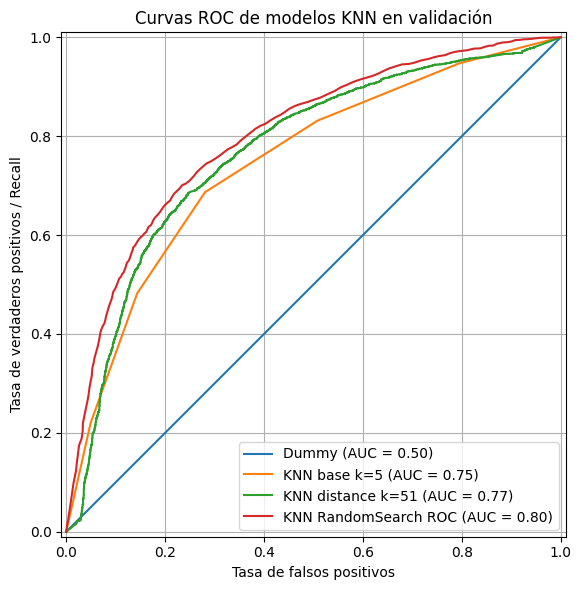

In [21]:
fig, ax = plt.subplots(figsize=(8, 6))

for model_name, model in all_knn_models.items():
    RocCurveDisplay.from_estimator(
        model,
        X_val,
        y_val,
        ax=ax,
        name=model_name
    )

plt.title("Curvas ROC de modelos KNN en validación")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos / Recall")
plt.grid(True)
plt.tight_layout()
plt.show()

## 16. Ajuste de threshold en validación

El modelo se selecciona por ROC-AUC. Después, el threshold operativo se ajusta en validación usando F2, porque F2 prioriza recall y es relevante en el contexto cardiovascular.

Importante: el threshold se ajusta **solo en validation**, nunca en test.

In [22]:
val_scores = get_decision_scores(candidate_model, X_val)

threshold_grid = np.linspace(0.05, 0.95, 181)

threshold_results = []

for threshold in threshold_grid:
    y_val_pred_threshold = (val_scores >= threshold).astype(int)

    scores, cm = get_scores_from_predictions(
        y_true=y_val,
        y_pred=y_val_pred_threshold,
        y_score=val_scores,
        model_name=candidate_model_name,
        split_name=f"validation_threshold_{threshold:.3f}"
    )

    scores["threshold"] = threshold
    threshold_results.append(scores)

threshold_results_df = pd.DataFrame(threshold_results)

threshold_results_sorted = threshold_results_df.sort_values(
    by=["f2", "FN", "recall"],
    ascending=[False, True, False]
)

threshold_results_sorted.head(10)

,model,split,accuracy,precision,recall,f1,f2,roc_auc,TN,FP,FN,TP,threshold
30,KNN RandomSearch ROC,validation_threshold_0.200,0.588424,0.547599,0.970554,0.700159,0.840688,0.799542,740,2723,100,3296,0.200
29,KNN RandomSearch ROC,validation_threshold_0.195,0.584196,0.544899,0.972026,0.698329,0.840291,0.799542,706,2757,95,3301,0.195
31,KNN RandomSearch ROC,validation_threshold_0.205,0.592215,0.550126,0.967903,0.701526,0.840278,0.799542,775,2688,109,3287,0.205
21,KNN RandomSearch ROC,validation_threshold_0.155,0.549205,0.523691,0.989399,0.684876,0.840000,0.799542,407,3056,36,3360,0.155
22,KNN RandomSearch ROC,validation_threshold_0.160,0.553725,0.526299,0.987044,0.686534,0.839974,0.799542,446,3017,44,3352,0.160
18,KNN RandomSearch ROC,validation_threshold_0.140,0.538562,0.517707,0.994405,0.680915,0.839757,0.799542,317,3146,19,3377,0.140
27,KNN RandomSearch ROC,validation_threshold_0.185,0.572387,0.537502,0.977032,0.693489,0.839702,0.799542,608,2855,78,3318,0.185
28,KNN RandomSearch ROC,validation_threshold_0.190,0.577635,0.540801,0.973793,0.695405,0.839383,0.799542,655,2808,89,3307,0.190
24,KNN RandomSearch ROC,validation_threshold_0.170,0.560286,0.530187,0.982627,0.688751,0.839370,0.799542,506,2957,59,3337,0.170
33,KNN RandomSearch ROC,validation_threshold_0.215,0.600525,0.555801,0.962014,0.704550,0.839328,0.799542,852,2611,129,3267,0.215


In [23]:
best_threshold = float(threshold_results_sorted.iloc[0]["threshold"])

print("Mejor threshold según F2 en validation:", best_threshold)

best_threshold_val_scores = threshold_results_sorted.iloc[0]
best_threshold_val_scores

Mejor threshold según F2 en validation: 0.19999999999999996


model              KNN RandomSearch ROC
split        validation_threshold_0.200
accuracy                       0.588424
precision                      0.547599
recall                         0.970554
f1                             0.700159
f2                             0.840688
roc_auc                        0.799542
TN                                  740
FP                                 2723
FN                                  100
TP                                 3296
threshold                           0.2
Name: 30, dtype: object

## 16.1 Curva de métricas por threshold

Esta gráfica ayuda a justificar el threshold ajustado por F2.

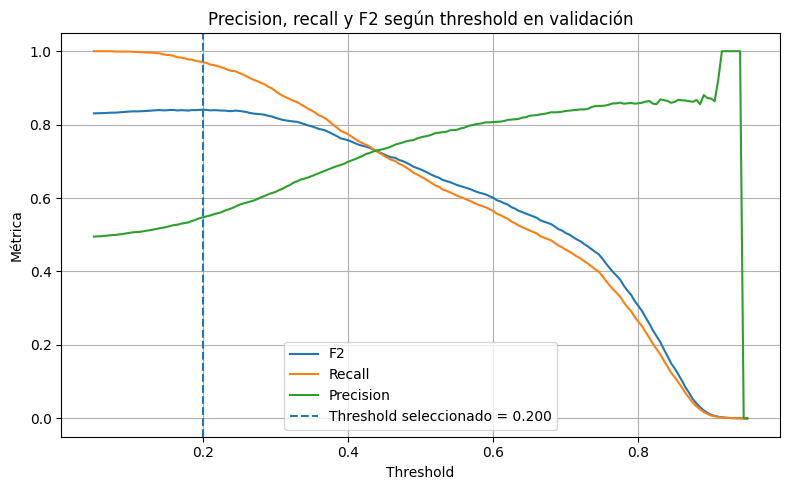

In [24]:
selected_threshold_for_plot = float(threshold_results_sorted.iloc[0]["threshold"])

plt.figure(figsize=(8, 5))

plt.plot(threshold_results_df["threshold"], threshold_results_df["f2"], label="F2")
plt.plot(threshold_results_df["threshold"], threshold_results_df["recall"], label="Recall")
plt.plot(threshold_results_df["threshold"], threshold_results_df["precision"], label="Precision")

plt.axvline(
    selected_threshold_for_plot,
    linestyle="--",
    label=f"Threshold seleccionado = {selected_threshold_for_plot:.3f}"
)

plt.xlabel("Threshold")
plt.ylabel("Métrica")
plt.title("Precision, recall y F2 según threshold en validación")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## 17. Matriz de confusión en validación con threshold ajustado

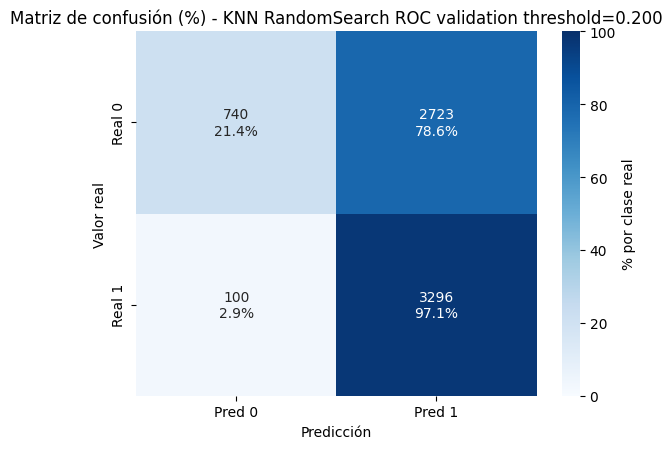

,model,split,accuracy,precision,recall,f1,f2,roc_auc,TN,FP,FN,TP
0,KNN RandomSearch ROC,validation_adjusted_threshold,0.588424,0.547599,0.970554,0.700159,0.840688,0.799542,740,2723,100,3296


In [25]:
y_val_pred_adjusted = (val_scores >= best_threshold).astype(int)

val_adjusted_scores, val_adjusted_cm = get_scores_from_predictions(
    y_true=y_val,
    y_pred=y_val_pred_adjusted,
    y_score=val_scores,
    model_name=candidate_model_name,
    split_name="validation_adjusted_threshold"
)

plot_confusion_matrix_percent(
    val_adjusted_cm,
    title=f"Matriz de confusión (%) - {candidate_model_name} validation threshold={best_threshold:.3f}",
    class_labels=("0", "1")
)

pd.DataFrame([val_adjusted_scores])

## 18. Evaluación final en test

Se evalúa en test usando:

1. threshold por defecto 0.5;
2. threshold ajustado en validation.

El test no se usa para escoger modelo ni threshold.

In [26]:
test_scores_raw = get_decision_scores(candidate_model, X_test)

test_pred_default = (test_scores_raw >= 0.5).astype(int)
test_default_scores, test_default_cm = get_scores_from_predictions(
    y_true=y_test,
    y_pred=test_pred_default,
    y_score=test_scores_raw,
    model_name=candidate_model_name,
    split_name="test_default_threshold"
)

test_pred_adjusted = (test_scores_raw >= best_threshold).astype(int)
test_adjusted_scores, test_adjusted_cm = get_scores_from_predictions(
    y_true=y_test,
    y_pred=test_pred_adjusted,
    y_score=test_scores_raw,
    model_name=candidate_model_name,
    split_name="test_adjusted_threshold"
)

test_results = pd.DataFrame([
    test_default_scores,
    test_adjusted_scores
])

test_results

,model,split,accuracy,precision,recall,f1,f2,roc_auc,TN,FP,FN,TP
0,KNN RandomSearch ROC,test_default_threshold,0.732906,0.771637,0.653903,0.707908,0.674485,0.798452,2807,657,1175,2220
1,KNN RandomSearch ROC,test_adjusted_threshold,0.579822,0.542488,0.964654,0.694444,0.834735,0.798452,702,2762,120,3275


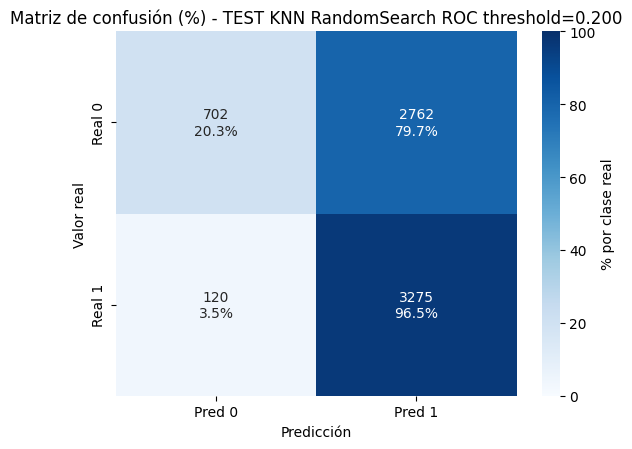

In [27]:
plot_confusion_matrix_percent(
    test_adjusted_cm,
    title=f"Matriz de confusión (%) - TEST {candidate_model_name} threshold={best_threshold:.3f}",
    class_labels=("0", "1")
)

In [28]:
print(classification_report(
    y_test,
    test_pred_adjusted,
    zero_division=0
))

              precision    recall  f1-score   support

           0       0.85      0.20      0.33      3464
           1       0.54      0.96      0.69      3395

    accuracy                           0.58      6859
   macro avg       0.70      0.58      0.51      6859
weighted avg       0.70      0.58      0.51      6859



## 19. Exportar modelo KNN seleccionado


In [37]:
import joblib

MODEL_FILENAME = "exported_knn.joblib"
MODEL_PATH = Path(MODEL_FILENAME)

model_bundle = {
    "model": candidate_model,
    "model_name": candidate_model_name,
    "threshold": float(best_threshold),
    "target_column": target_column,
    "feature_columns": list(X_train.columns),
    "official_metric": official_refit_metric,
    "validation_results": all_validation_results,
    "threshold_validation_results": threshold_results_sorted,
    "test_results": test_results,
    "search_best_params": knn_random_search.best_params_,
    "search_best_cv_score": float(knn_random_search.best_score_),
    "search_training_size": int(len(X_train)),
    "search_cv_strategy": "KFold(n_splits=3, shuffle=True, random_state=42)",
    "search_n_iter": int(N_ITER)
}

joblib.dump(model_bundle, MODEL_PATH)

print(f"Modelo exportado correctamente en: {MODEL_PATH.resolve()}")

Modelo exportado correctamente en: /kaggle/working/exported_knn.joblib


## 20. Ejemplo de carga del modelo exportado

In [38]:
loaded_bundle = joblib.load("exported_knn.joblib")

loaded_model = loaded_bundle["model"]
loaded_threshold = loaded_bundle["threshold"]

loaded_scores = get_decision_scores(loaded_model, X_test)
loaded_predictions = (loaded_scores >= loaded_threshold).astype(int)

loaded_predictions[:10]

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [39]:
original_predictions = (get_decision_scores(candidate_model, X_test) >= best_threshold).astype(int)

print("Predicciones iguales:", (original_predictions == loaded_predictions).all())

Predicciones iguales: True
